In [10]:
import numpy as np
import pandas as pd

books = pd.read_csv('../Dataset/Books.csv')
users = pd.read_csv('../Dataset/Users.csv')
ratings = pd.read_csv('../Dataset/Ratings.csv')


C:\Users\manan\AppData\Local\Temp\ipykernel_57732\3208241500.py:4: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('../Dataset/Books.csv')


In [11]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [12]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [13]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [14]:
print(books.shape)
print(ratings.shape)
print(users.shape)

(271360, 8)
(1149780, 3)
(278858, 3)


In [15]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [16]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [17]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [18]:
books.duplicated().sum()

np.int64(0)

In [19]:
ratings.duplicated().sum()

np.int64(0)

In [20]:
users.duplicated().sum()

np.int64(0)

## EDA

Ratings

In [21]:
lowest_rating = ratings['Book-Rating'].min()
print(f"Lowest Rating is {lowest_rating}")

highest_rating = ratings['Book-Rating'].max()
print(f"Highest Rating is {highest_rating}")

Lowest Rating is 0
Highest Rating is 10


In [22]:
# Filter explicit ratings only (exclude 0)
explicit_ratings = ratings[ratings['Book-Rating'] > 0].copy()

In [23]:
explicit_ratings

,User-ID,ISBN,Book-Rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
6,276736,3257224281,8
7,276737,0600570967,6
...,...,...,...
1149773,276704,0806917695,5
1149775,276704,1563526298,9
1149777,276709,0515107662,10
1149778,276721,0590442449,10


In [24]:
# Ratings Distribution
ratings_distribution = explicit_ratings['Book-Rating'].value_counts().sort_index()
ratings_distribution

Book-Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

Books

In [25]:
# Clean Books dataset
# Convert Year-Of-Publication to numeric, set errors to NaN, then drop NaNs and cast to int
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')

# After the above line, we need to perform the following steps to drop the NaN and covert the year to int as pd.to_numeric convert it into float values
# books = books.dropna(subset=['Year-Of-Publication'])
# books['Year-Of-Publication'] = books['Year-Of-Publication'].astype(int)

# Convert Year-Of-Publication to numeric, set errors to NaN, then drop NaNs and cast to int

# Drop rows with invalid or missing years
valid_books = books[(books['Year-Of-Publication'] >= 1500) & (books['Year-Of-Publication'] <= 2025)].copy()
valid_books['Year-Of-Publication'] = valid_books['Year-Of-Publication'].astype(int)

# There are only 3 books which are older than 1800 ie, 0, 1376 and 1378 so we remove them

# Find the oldest book
oldest_year = valid_books['Year-Of-Publication'].min()
oldest_books = valid_books[valid_books['Year-Of-Publication'] == oldest_year]

# Find the newest book
newest_year = valid_books['Year-Of-Publication'].max()
newest_books = valid_books[valid_books['Year-Of-Publication'] == newest_year]

# Print Oldest Books
print(f"Oldest Book(s) Published in {oldest_year}:")
for idx, row in oldest_books.iterrows():
    print(f"🔹 '{row['Book-Title']}' by {row['Book-Author']}\n")

# Print Newest Books
print(f"Newest Book(s) Published in {newest_year}:")
for idx, row in newest_books.iterrows():
    print(f"🔹 '{row['Book-Title']}' by {row['Book-Author']}")

Oldest Book(s) Published in 1806:
🔹 'Complete Works 10 Volumes [2,6,7,8,9] (Notable American Authors)' by Benjamin Franklin

Newest Book(s) Published in 2024:
🔹 'CLOUT' by D. GIBBONS


In [26]:
# Top 10 Most Rated Books

top_books = explicit_ratings['ISBN'].value_counts().head(10).reset_index()
top_books.columns = ['ISBN', 'Rating Count']
top_books = top_books.merge(books[['ISBN', 'Book-Title', 'Book-Author']], on='ISBN', how='left')

top_books.index = pd.RangeIndex(start=1, stop=len(top_books) + 1)

print("Top 10 Most Rated Books:\n")
top_books

Top 10 Most Rated Books:



,ISBN,Rating Count,Book-Title,Book-Author
1,0316666343,707,The Lovely Bones: A Novel,Alice Sebold
2,0971880107,581,Wild Animus,Rich Shapero
3,0385504209,487,The Da Vinci Code,Dan Brown
4,0312195516,383,The Red Tent (Bestselling Backlist),Anita Diamant
5,0679781587,333,NaN,NaN
6,0060928336,320,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells
7,059035342X,313,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling
8,0142001740,307,The Secret Life of Bees,Sue Monk Kidd
9,0446672211,295,Where the Heart Is (Oprah's Book Club (Paperba...,Billie Letts
10,044023722X,281,A Painted House,John Grisham


Users

In [27]:
# Clean Users dataset
users['Age'] = pd.to_numeric(users['Age'], errors='coerce')
users = users[(users['Age'] >= 5) & (users['Age'] <= 100)]
users['Age'] = users['Age'].astype(int)

In [28]:
# Top 10 Most Active Users
top_users = explicit_ratings['User-ID'].value_counts().head(10).reset_index()
top_users.columns = ['User-ID', 'Rating Count']
top_users.index = pd.RangeIndex(start=1, stop=len(top_users) + 1)
print("Top 10 Most Active Users:")
top_users

Top 10 Most Active Users:


,User-ID,Rating Count
1,11676,8524
2,98391,5802
3,153662,1969
4,189835,1906
5,23902,1395
6,76499,1036
7,171118,1035
8,235105,1023
9,16795,968
10,248718,948


In [29]:
# Average Rating by Age

ratings_users = explicit_ratings.merge(users, on='User-ID')
age_avg_rating = ratings_users.groupby('Age')['Book-Rating'].mean().reset_index()
age_avg_rating.index = pd.RangeIndex(start=1, stop=len(age_avg_rating) + 1)
print("Average Rating by Age:")
age_avg_rating

Average Rating by Age:


,Age,Book-Rating
1,5,7.092308
2,6,7.363636
3,7,7.838710
4,8,7.805556
5,9,7.077612
...,...,...
89,96,8.500000
90,97,8.768421
91,98,7.000000
92,99,8.800000


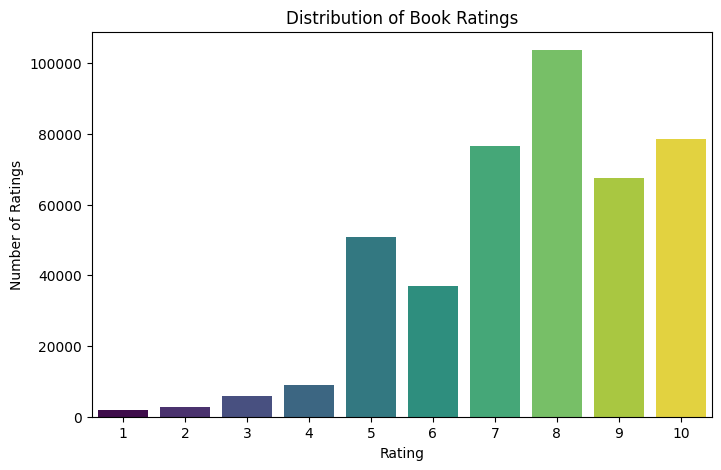

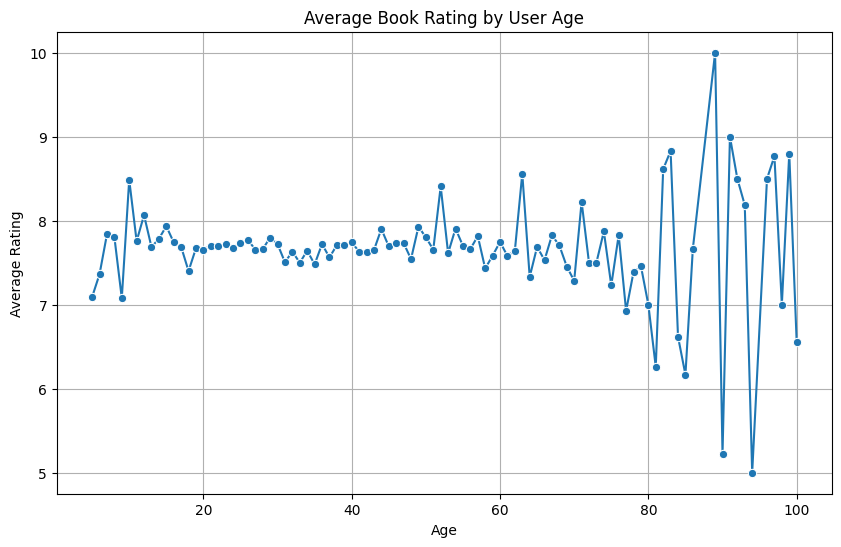

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rating Distribution Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=ratings_distribution.index, y=ratings_distribution.values, hue=ratings_distribution.index, palette='viridis', legend=False)
plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()

# Age vs Average Rating Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=age_avg_rating, x='Age', y='Book-Rating', marker='o')
plt.title('Average Book Rating by User Age')
plt.xlabel('Age')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()


# Model Building
### Popularity Based Recommendation System
We will shows top 50 books with average highest rating but we will consider books which get a minimum of 250 votes.

In [31]:
ratings.merge(books, on='ISBN').shape

(1031136, 10)

In [32]:
ratings_with_book_name = ratings.merge(books, on='ISBN')

In [33]:
ratings_with_book_name

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001.0,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996.0,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
...,...,...,...,...,...,...,...,...,...,...
1031131,276704,0876044011,0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,1998.0,A.R.E. Press (Association of Research &amp; Enlig,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...
1031132,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000.0,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997.0,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996.0,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...


In [34]:
num_rating_df = ratings_with_book_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_rating_df = num_rating_df.rename(columns={'Book-Rating':'Number-Of-Rating'})
num_rating_df

,Book-Title,Number-Of-Rating
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [35]:
avg_rating_df = ratings_with_book_name.groupby('Book-Title')['Book-Rating'].mean().reset_index()
avg_rating_df = avg_rating_df.rename(columns={'Book-Rating': 'Avg-Rating'})
avg_rating_df

,Book-Title,Avg-Rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [36]:
popular_df = num_rating_df.merge(avg_rating_df, on='Book-Title')
popular_df

,Book-Title,Number-Of-Rating,Avg-Rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [37]:
popular_df = popular_df[popular_df['Number-Of-Rating'] >= 250].sort_values('Avg-Rating', ascending=False).head(50)

In [38]:
popular_df = popular_df.merge(books, on='Book-Title').drop_duplicates('Book-Title')
# As there are multiple ISBN for a single book so we drop the duplicate books

In [39]:
popular_df = popular_df[['Book-Title', 'Book-Author', 'Image-URL-M', 'Number-Of-Rating', 'Avg-Rating']]
popular_df

,Book-Title,Book-Author,Image-URL-M,Number-Of-Rating,Avg-Rating
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136350.0...,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139597.0...,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/0590353403.0...,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,http://images.amazon.com/images/P/043935806X.0...,347,5.501441
13,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,http://images.amazon.com/images/P/0439064872.0...,556,5.183453
16,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339681.0...,281,5.007117
17,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339703.0...,368,4.948370
26,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,http://images.amazon.com/images/P/059035342X.0...,575,4.895652
28,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339711.0...,260,4.880769
39,To Kill a Mockingbird,Harper Lee,http://images.amazon.com/images/P/0446310786.0...,510,4.700000


In [40]:
# Use this if there are NaN values and you are not sure about all the values are string or not

# Convert all 'http' image links to 'https' in the 'Image-URL-M' column
# popular_df['Image-URL-M'] = popular_df['Image-URL-M'].apply(lambda url: url.replace("http://", "https://") if isinstance(url, str) else url)

In [41]:
# Convert all 'http' image links to 'https' in the 'Image-URL-M' column
popular_df['Image-URL-M'] = popular_df['Image-URL-M'].str.replace("http://", "https://", regex=False)

In [42]:
popular_df

,Book-Title,Book-Author,Image-URL-M,Number-Of-Rating,Avg-Rating
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,https://images.amazon.com/images/P/0439136350....,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,https://images.amazon.com/images/P/0439139597....,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,https://images.amazon.com/images/P/0590353403....,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,https://images.amazon.com/images/P/043935806X....,347,5.501441
13,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,https://images.amazon.com/images/P/0439064872....,556,5.183453
16,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,https://images.amazon.com/images/P/0345339681....,281,5.007117
17,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,https://images.amazon.com/images/P/0345339703....,368,4.948370
26,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,https://images.amazon.com/images/P/059035342X....,575,4.895652
28,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,https://images.amazon.com/images/P/0345339711....,260,4.880769
39,To Kill a Mockingbird,Harper Lee,https://images.amazon.com/images/P/0446310786....,510,4.700000


## Collaborative Filtering Based Recommender System
We will make a dataframe with books as rows and different users as columns. The Df will contain the rating by each user respective to the book. But we will consider only those users who have rated atleast 200 books and consider only those books which got rating by atleast 50 users.

In [43]:
ratings_with_book_name

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001.0,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996.0,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
...,...,...,...,...,...,...,...,...,...,...
1031131,276704,0876044011,0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,1998.0,A.R.E. Press (Association of Research &amp; Enlig,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...
1031132,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000.0,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997.0,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996.0,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...


In [44]:
x = ratings_with_book_name.groupby('User-ID').count()['Book-Rating'] > 200

In [45]:
x[x]    # boolean indexing

User-ID
254       True
2276      True
2766      True
2977      True
3363      True
          ... 
274308    True
275970    True
277427    True
277639    True
278418    True
Name: Book-Rating, Length: 811, dtype: bool

In [46]:
potential_users = x[x].index
potential_users
# index of all the users who have rated atleast 200 books

Index([   254,   2276,   2766,   2977,   3363,   4017,   4385,   6251,   6323,
         6543,
       ...
       271705, 273979, 274004, 274061, 274301, 274308, 275970, 277427, 277639,
       278418],
      dtype='int64', name='User-ID', length=811)

In [47]:
filtered_rating = ratings_with_book_name[ratings_with_book_name['User-ID'].isin(potential_users)]

In [48]:
filtered_rating

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994.0,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
1151,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995.0,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...,http://images.amazon.com/images/P/0026217457.0...,http://images.amazon.com/images/P/0026217457.0...
1152,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974.0,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...,http://images.amazon.com/images/P/003008685X.0...,http://images.amazon.com/images/P/003008685X.0...
1153,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982.0,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...,http://images.amazon.com/images/P/0030615321.0...,http://images.amazon.com/images/P/0030615321.0...
1154,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002.0,Avon Books,http://images.amazon.com/images/P/0060002050.0...,http://images.amazon.com/images/P/0060002050.0...,http://images.amazon.com/images/P/0060002050.0...
...,...,...,...,...,...,...,...,...,...,...
1029357,275970,1931868123,0,There's a Porcupine in My Outhouse: Misadventu...,Mike Tougias,2002.0,Capital Books (VA),http://images.amazon.com/images/P/1931868123.0...,http://images.amazon.com/images/P/1931868123.0...,http://images.amazon.com/images/P/1931868123.0...
1029358,275970,3411086211,10,Die Biene.,Sybil GrÃ?Â¤fin SchÃ?Â¶nfeldt,1993.0,"Bibliographisches Institut, Mannheim",http://images.amazon.com/images/P/3411086211.0...,http://images.amazon.com/images/P/3411086211.0...,http://images.amazon.com/images/P/3411086211.0...
1029359,275970,3829021860,0,The Penis Book,Joseph Cohen,1999.0,Konemann,http://images.amazon.com/images/P/3829021860.0...,http://images.amazon.com/images/P/3829021860.0...,http://images.amazon.com/images/P/3829021860.0...
1029360,275970,4770019572,0,Musashi,Eiji Yoshikawa,1995.0,Kodansha International (JPN),http://images.amazon.com/images/P/4770019572.0...,http://images.amazon.com/images/P/4770019572.0...,http://images.amazon.com/images/P/4770019572.0...


In [49]:
y = filtered_rating.groupby('Book-Title').count()['Book-Rating'] >= 50
y[y]

Book-Title
1984                                                                 True
1st to Die: A Novel                                                  True
2nd Chance                                                           True
4 Blondes                                                            True
A Bend in the Road                                                   True
                                                                     ... 
Year of Wonders                                                      True
You Belong To Me                                                     True
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values    True
Zoya                                                                 True
\O\" Is for Outlaw"                                                  True
Name: Book-Rating, Length: 706, dtype: bool

In [50]:
famous_books = y[y].index
famous_books

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Day Late and a Dollar Short', 'A Fine Balance',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='str', name='Book-Title', length=706)

In [51]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [52]:
final_ratings

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994.0,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
1163,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999.0,Perennial,http://images.amazon.com/images/P/0060930535.0...,http://images.amazon.com/images/P/0060930535.0...,http://images.amazon.com/images/P/0060930535.0...
1165,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002.0,Perennial,http://images.amazon.com/images/P/0060934417.0...,http://images.amazon.com/images/P/0060934417.0...,http://images.amazon.com/images/P/0060934417.0...
1168,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995.0,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,http://images.amazon.com/images/P/0061009059.0...,http://images.amazon.com/images/P/0061009059.0...
1174,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998.0,HarperTrophy,http://images.amazon.com/images/P/006440188X.0...,http://images.amazon.com/images/P/006440188X.0...,http://images.amazon.com/images/P/006440188X.0...
...,...,...,...,...,...,...,...,...,...,...
1029196,275970,1400031354,0,Tears of the Giraffe (No.1 Ladies Detective Ag...,Alexander McCall Smith,2002.0,Anchor,http://images.amazon.com/images/P/1400031354.0...,http://images.amazon.com/images/P/1400031354.0...,http://images.amazon.com/images/P/1400031354.0...
1029197,275970,1400031362,0,Morality for Beautiful Girls (No.1 Ladies Dete...,Alexander McCall Smith,2002.0,Anchor,http://images.amazon.com/images/P/1400031362.0...,http://images.amazon.com/images/P/1400031362.0...,http://images.amazon.com/images/P/1400031362.0...
1029270,275970,1573229725,0,Fingersmith,Sarah Waters,2002.0,Riverhead Books,http://images.amazon.com/images/P/1573229725.0...,http://images.amazon.com/images/P/1573229725.0...,http://images.amazon.com/images/P/1573229725.0...
1029309,275970,1586210661,9,Me Talk Pretty One Day,David Sedaris,2001.0,Time Warner Audio Major,http://images.amazon.com/images/P/1586210661.0...,http://images.amazon.com/images/P/1586210661.0...,http://images.amazon.com/images/P/1586210661.0...


In [53]:
pt = final_ratings.pivot_table(index='Book-Title', columns='User-ID', values='Book-Rating')
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1st to Die: A Novel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2nd Chance,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
4 Blondes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A Bend in the Road,0.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,9.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
You Belong To Me,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


I used 0 to represent missing interactions for computational simplicity, especially for cosine similarity. However, I understand that 0 doesn’t mean dislike — it’s just a placeholder. In production systems, more sophisticated techniques like sparse matrices or implicit feedback handling are used. 
0 means no interaction, not dislike

In [54]:
row_mean = pt.mean(axis=1)
# pt.fillna(pt.mean(axis=1), inplace=True)
row_mean

# As the row mean is narly 0 so we will fill Null values with 0

Book-Title
1984                                                                 3.217172
1st to Die: A Novel                                                  2.281457
2nd Chance                                                           2.411504
4 Blondes                                                            0.985714
A Bend in the Road                                                   1.637615
                                                                       ...   
Year of Wonders                                                      3.070175
You Belong To Me                                                     1.545455
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values    1.983333
Zoya                                                                 1.103448
\O\" Is for Outlaw"                                                  2.074468
Length: 706, dtype: float64

In [55]:
pt.fillna(0, inplace=True)
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
from sklearn.metrics.pairwise import cosine_similarity

##### It measures how similar two vectors are by calculating the angle between them, not the magnitude
##### Cosine similarity measures similarity between two vectors based on the angle between them. In recommendation systems, it helps identify items with similar user interaction patterns regardless of rating scale.

In [57]:
similarity_score = cosine_similarity(pt)

In [58]:
similarity_score.shape

(706, 706)

In [59]:
similarity_score
# This shows the similarity score of each book with each book.

array([[1.        , 0.10255025, 0.01220856, ..., 0.12110367, 0.07347567,
        0.04316046],
       [0.10255025, 1.        , 0.2364573 , ..., 0.07446129, 0.16773875,
        0.14263397],
       [0.01220856, 0.2364573 , 1.        , ..., 0.04558758, 0.04938579,
        0.10796119],
       ...,
       [0.12110367, 0.07446129, 0.04558758, ..., 1.        , 0.07085128,
        0.0196177 ],
       [0.07347567, 0.16773875, 0.04938579, ..., 0.07085128, 1.        ,
        0.10602962],
       [0.04316046, 0.14263397, 0.10796119, ..., 0.0196177 , 0.10602962,
        1.        ]], shape=(706, 706))

In [60]:
similarity_score[0]
# similarity score of 1st book with each other book

array([1.        , 0.10255025, 0.01220856, 0.        , 0.05367224,
       0.02774901, 0.08216491, 0.13732869, 0.03261686, 0.03667591,
       0.02322418, 0.06766487, 0.02083978, 0.09673735, 0.13388865,
       0.08303112, 0.11153543, 0.05100411, 0.02517784, 0.11706383,
       0.        , 0.14333793, 0.07847534, 0.06150451, 0.08723968,
       0.        , 0.07009814, 0.13658681, 0.07600328, 0.12167134,
       0.00768046, 0.01473221, 0.        , 0.07965814, 0.04522617,
       0.01556271, 0.09495938, 0.0182307 , 0.02610465, 0.07984012,
       0.11679969, 0.0569124 , 0.08354155, 0.08471898, 0.08785938,
       0.05491435, 0.0548505 , 0.27026514, 0.09779123, 0.06016046,
       0.08958835, 0.06748675, 0.        , 0.04468098, 0.01920872,
       0.        , 0.05629067, 0.00557964, 0.07877059, 0.05219479,
       0.18908177, 0.        , 0.01240656, 0.02984572, 0.04279502,
       0.12680125, 0.16566735, 0.        , 0.13357242, 0.06615478,
       0.        , 0.        , 0.        , 0.10968075, 0.02806

In [61]:
df = pd.DataFrame(similarity_score)
df

,0,1,2,3,4,5,6,7,8,9,...,696,697,698,699,700,701,702,703,704,705
0,1.000000,0.102550,0.012209,0.000000,0.053672,0.027749,0.082165,0.137329,0.032617,0.036676,...,0.052372,0.011402,0.009687,0.125306,0.009099,0.058641,0.017696,0.121104,0.073476,0.043160
1,0.102550,1.000000,0.236457,0.000000,0.109538,0.100929,0.117862,0.187620,0.096589,0.047161,...,0.066278,0.077286,0.152550,0.084055,0.063633,0.052353,0.193097,0.074461,0.167739,0.142634
2,0.012209,0.236457,1.000000,0.000000,0.069090,0.105591,0.000000,0.107744,0.067022,0.041682,...,0.153473,0.183089,0.019906,0.148580,0.018697,0.068549,0.165654,0.045588,0.049386,0.107961
3,0.000000,0.000000,0.000000,1.000000,0.000000,0.111582,0.000000,0.000000,0.074396,0.000000,...,0.000000,0.000000,0.000000,0.011948,0.123486,0.108638,0.076242,0.000000,0.000000,0.000000
4,0.053672,0.109538,0.069090,0.000000,1.000000,0.101331,0.096270,0.039933,0.074522,0.000000,...,0.076387,0.082158,0.022133,0.075816,0.025587,0.000000,0.098488,0.040017,0.112841,0.015204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701,0.058641,0.052353,0.068549,0.108638,0.000000,0.064919,0.000000,0.131434,0.126245,0.072397,...,0.181184,0.000000,0.000000,0.000000,0.071845,1.000000,0.000000,0.000000,0.081330,0.000000
702,0.017696,0.193097,0.165654,0.076242,0.098488,0.119383,0.080976,0.052059,0.097149,0.169927,...,0.202358,0.159737,0.028853,0.061184,0.027101,0.000000,1.000000,0.052168,0.194303,0.190658
703,0.121104,0.074461,0.045588,0.000000,0.040017,0.094787,0.042405,0.051525,0.197962,0.000000,...,0.039791,0.048550,0.028558,0.198973,0.026824,0.000000,0.052168,1.000000,0.070851,0.019618
704,0.073476,0.167739,0.049386,0.000000,0.112841,0.112250,0.153617,0.070702,0.131941,0.087917,...,0.110764,0.046122,0.039187,0.083096,0.036807,0.081330,0.194303,0.070851,1.000000,0.106030


### Run Function 3 after this 

Formulation


In [62]:
pt.index

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Day Late and a Dollar Short', 'A Fine Balance',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='str', name='Book-Title', length=706)

In [63]:
index = pt.index.get_loc('Message in a Bottle')
index

322

In [64]:
index = pt.index.get_loc('Message in a Bottle')
distances = similarity_score[index]

similar_df = pd.DataFrame({
    'Book-Title': pt.index,
    'Similarity': distances
})

similar_df

,Book-Title,Similarity
0,1984,0.070088
1,1st to Die: A Novel,0.057648
2,2nd Chance,0.152903
3,4 Blondes,0.142850
4,A Bend in the Road,0.115154
...,...,...
701,Year of Wonders,0.060101
702,You Belong To Me,0.105195
703,Zen and the Art of Motorcycle Maintenance: An ...,0.018977
704,Zoya,0.019706


In [65]:
# similar_df = similar_df.merge(avg_rating_df, on='Book-Title')
# similar_df = similar_df.merge(num_rating_df, on='Book-Title')
similar_df = similar_df.merge(avg_rating_df[['Book-Title', 'Avg-Rating']], on='Book-Title')
similar_df = similar_df.merge(num_rating_df[['Book-Title', 'Number-Of-Rating']], on='Book-Title')
similar_df

,Book-Title,Similarity,Avg-Rating,Number-Of-Rating
0,1984,0.070088,4.454225,284
1,1st to Die: A Novel,0.057648,3.575639,509
2,2nd Chance,0.152903,3.269663,356
3,4 Blondes,0.142850,1.947020,151
4,A Bend in the Road,0.115154,3.364162,346
...,...,...,...,...
701,Year of Wonders,0.060101,4.331361,169
702,You Belong To Me,0.105195,2.731707,123
703,Zen and the Art of Motorcycle Maintenance: An ...,0.018977,3.147619,210
704,Zoya,0.019706,1.466019,103


In [66]:
# Function 2
# def recommend(book_name):
#     index = pt.index.get_loc(book_name)
#     distances = similarity_score[index]

#     similar_df = pd.DataFrame({
#         'Book-Title': pt.index,
#         'Similarity': distances
#     })

#     similar_df = similar_df.merge(avg_rating_df[['Book-Title', 'Avg-Rating']], on='Book-Title')
#     similar_df = similar_df.merge(num_rating_df[['Book-Title', 'Number-Of-Rating']], on='Book-Title')

#     similar_df['Final Score'] = (
#         similar_df['Similarity'] *
#         similar_df['Avg-Rating'] *
#         np.log(similar_df['Number-Of-Rating'])
#     )

#     return similar_df.sort_values('Final Score', ascending=False).head(10)

# I used this code for finding similar books but it is giving some differnt books also as recommendation due to very high popularity of that certain book.

### To tackle this we can  
1. Give more weightage to similarity 
* score similar_df['Final Score'] = ((similar_df['Similarity'] ** 2) * similar_df['Avg-Rating'] * np.log(similar_df['Number-Of-Rating']))
2. Normalize popularity terms
* similar_df['norm_rating'] = similar_df['Avg-Rating'] / 5
3. Use Hard filter, Only consider sufficiently similar books
* similar_df = similar_df[similar_df['Similarity'] > 0.2] and then rank by multiplying with avg_rating and number of rating
4. Filter top similar books and then rank within them by popularity


In [67]:
# Step 1: filter similar books
similar_df = similar_df[similar_df['Similarity'] > 0.2]
similar_df = similar_df.sort_values('Similarity', ascending=False)

# Step 2: compute score
similar_df['Final Score'] = (
    similar_df['Similarity'] *
    np.log(similar_df['Number-Of-Rating'])
)

# Step 3: sort
recommendations = similar_df.sort_values('Final Score', ascending=False)

# There is a problem with this approach, as if there is a new book which is not much rated now then it will have a low similarity score and it will not recommend that many books or even 0 books. This is called "Cold Start" problem.
# But since we already picked up the books with atleast 50+ number of rating so it won't be a problem here.
# Instead of > 0.2, we can take only top 50 books according to the similarity score and then rank them,

In [68]:
recommendations

,Book-Title,Similarity,Avg-Rating,Number-Of-Rating,Final Score
322,Message in a Bottle,1.000000,2.778226,496,6.206576
24,A Walk to Remember,0.276965,3.399471,378,1.643757
355,Nights in Rodanthe,0.315508,3.497175,177,1.633116
573,The Mulberry Tree,0.282890,3.179487,156,1.428552
404,River's End,0.264093,2.242038,157,1.335320
36,All I Really Need to Know,0.223104,2.879845,258,1.238888
354,Nightmares &amp; Dreamscapes,0.238071,3.641379,145,1.184815
226,Hard Eight : A Stephanie Plum Novel (A Stephan...,0.207502,3.825279,269,1.160912
413,Sanctuary,0.225280,2.468354,158,1.140502
325,Midnight Bayou,0.211186,3.245902,183,1.100169


In [69]:
similarity_scores_list = list(enumerate(similarity_score[index]))
similarity_scores_list

[(0, np.float64(0.0700882246357741)),
 (1, np.float64(0.057648256612230886)),
 (2, np.float64(0.15290269795945388)),
 (3, np.float64(0.14284952400575568)),
 (4, np.float64(0.11515387663800894)),
 (5, np.float64(0.060671665320849257)),
 (6, np.float64(0.03467489582710063)),
 (7, np.float64(0.014330662639125469)),
 (8, np.float64(0.026743105574091222)),
 (9, np.float64(0.046777395492685815)),
 (10, np.float64(0.019041892590920758)),
 (11, np.float64(0.010787689005142124)),
 (12, np.float64(0.0074755107946216474)),
 (13, np.float64(0.041495480599307015)),
 (14, np.float64(0.06977824085831336)),
 (15, np.float64(0.01791541719498984)),
 (16, np.float64(0.056486290130552244)),
 (17, np.float64(0.15619687095209903)),
 (18, np.float64(0.15777706833609118)),
 (19, np.float64(0.08569872402446346)),
 (20, np.float64(0.0)),
 (21, np.float64(0.0)),
 (22, np.float64(0.1463416173426988)),
 (23, np.float64(0.0)),
 (24, np.float64(0.2769648191865072)),
 (25, np.float64(0.046835612560010044)),
 (26, np.

In [70]:
# Funtion 3
def recommend(book_name):
    # Step 1: get index
    index = np.where(pt.index == book_name)[0][0]
    
    # Step 2: get similarity scores
    similarity_scores_list = list(enumerate(similarity_score[index]))
    
    # Step 3: convert to DataFrame
    similar_df = pd.DataFrame(similarity_scores_list, columns=['Index', 'Similarity'])
    
    # Step 4: map index → book title
    similar_df['Book-Title'] = similar_df['Index'].apply(lambda x: pt.index[x])
    
    # Step 5: remove the same book
    similar_df = similar_df[similar_df['Book-Title'] != book_name]
    
    # Step 6: apply similarity threshold
    # similar_df = similar_df[similar_df['Similarity'] > 0.2]
    
    # Step 6: taking top 50 books according to similarity score 
    similar_df = similar_df.sort_values('Similarity', ascending=False).head(50)
    
    # Step 7: merge rating data
    similar_df = similar_df.merge(avg_rating_df[['Book-Title', 'Avg-Rating']], on='Book-Title')
    similar_df = similar_df.merge(num_rating_df[['Book-Title', 'Number-Of-Rating']], on='Book-Title')
    
    # Step 8: compute weighted score
    similar_df['Final Score'] = (
        similar_df['Similarity'] *
        (similar_df['Avg-Rating'] / 5) *    # we can remove avg rating from the formula
        np.log(similar_df['Number-Of-Rating'])
    )
    
    # Step 9: sort and take top 5
    similar_df = similar_df.sort_values('Final Score', ascending=False).head(5)
    
    # Step 10: print result
    for _, row in similar_df.iterrows():
        print(row['Book-Title'])
    # iterrows() returns each row as a (index, Series) pair. This means you get the row’s index and a Pandas Series object containing column names and their values.

In [71]:
# Function 1
# def recommend(book_name):
#     # index fetch
#     index = np.where(pt.index == book_name)[0][0]
#     similar_items = sorted(list(enumerate(similarity_score[index])), key=lambda x:x[1], reverse=True)[1:6]      # this will give top 5 books

#     for i in similar_items:
#         print(pt.index[i[0]])

# This is the original function to find the similar book but it only checks for similarity score which also recommends some low rated books also

## Function call 👇

In [72]:
recommend('Message in a Bottle')

Nights in Rodanthe
A Walk to Remember
The Mulberry Tree
Hard Eight : A Stephanie Plum Novel (A Stephanie Plum Novel)
The Five People You Meet in Heaven


Logic behind the recommender function

In [73]:
# Index of a specific book
print(np.where(pt.index == '1984')[0][0])

0


In [74]:
print(np.where(pt.index == '1984'))

(array([0]),)


In [75]:
sorted(list(enumerate(similarity_score[0])), key=lambda x:x[1], reverse=True)

[(0, np.float64(0.9999999999999998)),
 (47, np.float64(0.2702651417103732)),
 (545, np.float64(0.2639619371123497)),
 (82, np.float64(0.23669374347400993)),
 (634, np.float64(0.23299389358170394)),
 (551, np.float64(0.2262639743141286)),
 (181, np.float64(0.22222254415660225)),
 (500, np.float64(0.21057743765309012)),
 (344, np.float64(0.20675540390453995)),
 (554, np.float64(0.20025063706783053)),
 (520, np.float64(0.19972624710300058)),
 (527, np.float64(0.19656287691544358)),
 (488, np.float64(0.19511819825564608)),
 (552, np.float64(0.1920889620576415)),
 (318, np.float64(0.19182230688281934)),
 (624, np.float64(0.1892531370760997)),
 (598, np.float64(0.189213677823462)),
 (60, np.float64(0.18908176672188648)),
 (622, np.float64(0.18571699439818884)),
 (647, np.float64(0.1841081817659337)),
 (546, np.float64(0.18408910419891056)),
 (202, np.float64(0.18049207281616433)),
 (541, np.float64(0.17990898085771034)),
 (309, np.float64(0.17415730924332484)),
 (588, np.float64(0.1738182944

In [76]:
sorted(list(enumerate(similarity_score[0])), key=lambda x:x[1], reverse=True)[1:6]

[(47, np.float64(0.2702651417103732)),
 (545, np.float64(0.2639619371123497)),
 (82, np.float64(0.23669374347400993)),
 (634, np.float64(0.23299389358170394)),
 (551, np.float64(0.2262639743141286))]

In [77]:
popular_df['Image-URL-M'][0]

'https://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'

## Changing some of the image links

1

In [78]:
popular_df[popular_df['Book-Title'] == "The Hitchhiker's Guide to the Galaxy"]['Image-URL-M'].values[0]

'https://images.amazon.com/images/P/0671461494.01.MZZZZZZZ.jpg'

In [79]:
popular_df.loc[popular_df['Book-Title'] == 'The Hitchhiker\'s Guide to the Galaxy', 'Image-URL-M'] = 'https://m.media-amazon.com/images/I/71cmloZMY9L._AC_UY327_FMwebp_QL65_.jpg'

In [80]:
popular_df[popular_df['Book-Title'] == "The Hitchhiker's Guide to the Galaxy"]['Image-URL-M'].values[0]

'https://m.media-amazon.com/images/I/71cmloZMY9L._AC_UY327_FMwebp_QL65_.jpg'

2

In [81]:
popular_df.loc[popular_df['Book-Title'] == 'Outlander', 'Image-URL-M'] = 'https://m.media-amazon.com/images/I/51oGU5pdSZL._AC_UY327_FMwebp_QL65_.jpg'
popular_df[popular_df['Book-Title'] == 'Outlander']['Image-URL-M'].values[0]

'https://m.media-amazon.com/images/I/51oGU5pdSZL._AC_UY327_FMwebp_QL65_.jpg'

3

In [82]:
popular_df.loc[popular_df['Book-Title'] == 'The Color Purple', 'Image-URL-M'] = 'https://m.media-amazon.com/images/I/71f6DRbcrsL._AC_UY327_FMwebp_QL65_.jpg'
popular_df[popular_df['Book-Title'] == 'The Color Purple']['Image-URL-M'].values[0]

'https://m.media-amazon.com/images/I/71f6DRbcrsL._AC_UY327_FMwebp_QL65_.jpg'

## Exporting the dataframe

In [83]:
# This is to export the popular_df dataframe to the main code
import pickle
pickle.dump(popular_df, open('popular.pkl', 'wb'))